In [ ]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import numpy as np

# define model architecture
class CongestionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.resnet18(weights=None)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        
        self.regressor = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        x = self.regressor(x)
        return x.squeeze(1)

# load model
base_dir = os.getcwd()
model_path = os.path.join("../../",base_dir, "model",'congestion_cnn_model.pth')

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CongestionCNN().to(device)

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Model loaded successfully on {device}")

Model loaded successfully on cpu


In [22]:
# prediction function
def predict_image(model, image_path, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        score = model(image_tensor).item()
    
    return score, image

# get all images
image_folder = 'images'
image_files = [f for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]

print(f"Found {len(image_files)} images")

# predict all images
results = []
for filename in image_files:
    image_path = os.path.join(image_folder, filename)
    score, img = predict_image(model, image_path, device)
    results.append((filename, score, img))
    print(f"{filename}: {score:.4f}")

print("\nPrediction complete!")

Found 10 images
20251107_150939.jpg: 0.2773
20251107_150954.jpg: 0.4763
20251107_151009.jpg: 0.2702
20251107_151025.jpg: 0.2570
20251107_151040.jpg: 0.3850
20251112_123343.jpg: 0.2463
test_1.jpg: 0.5795
test_2.jpg: 0.4780
test_3_1.jpg: 0.6762
test_3_2.jpg: 0.6603

Prediction complete!


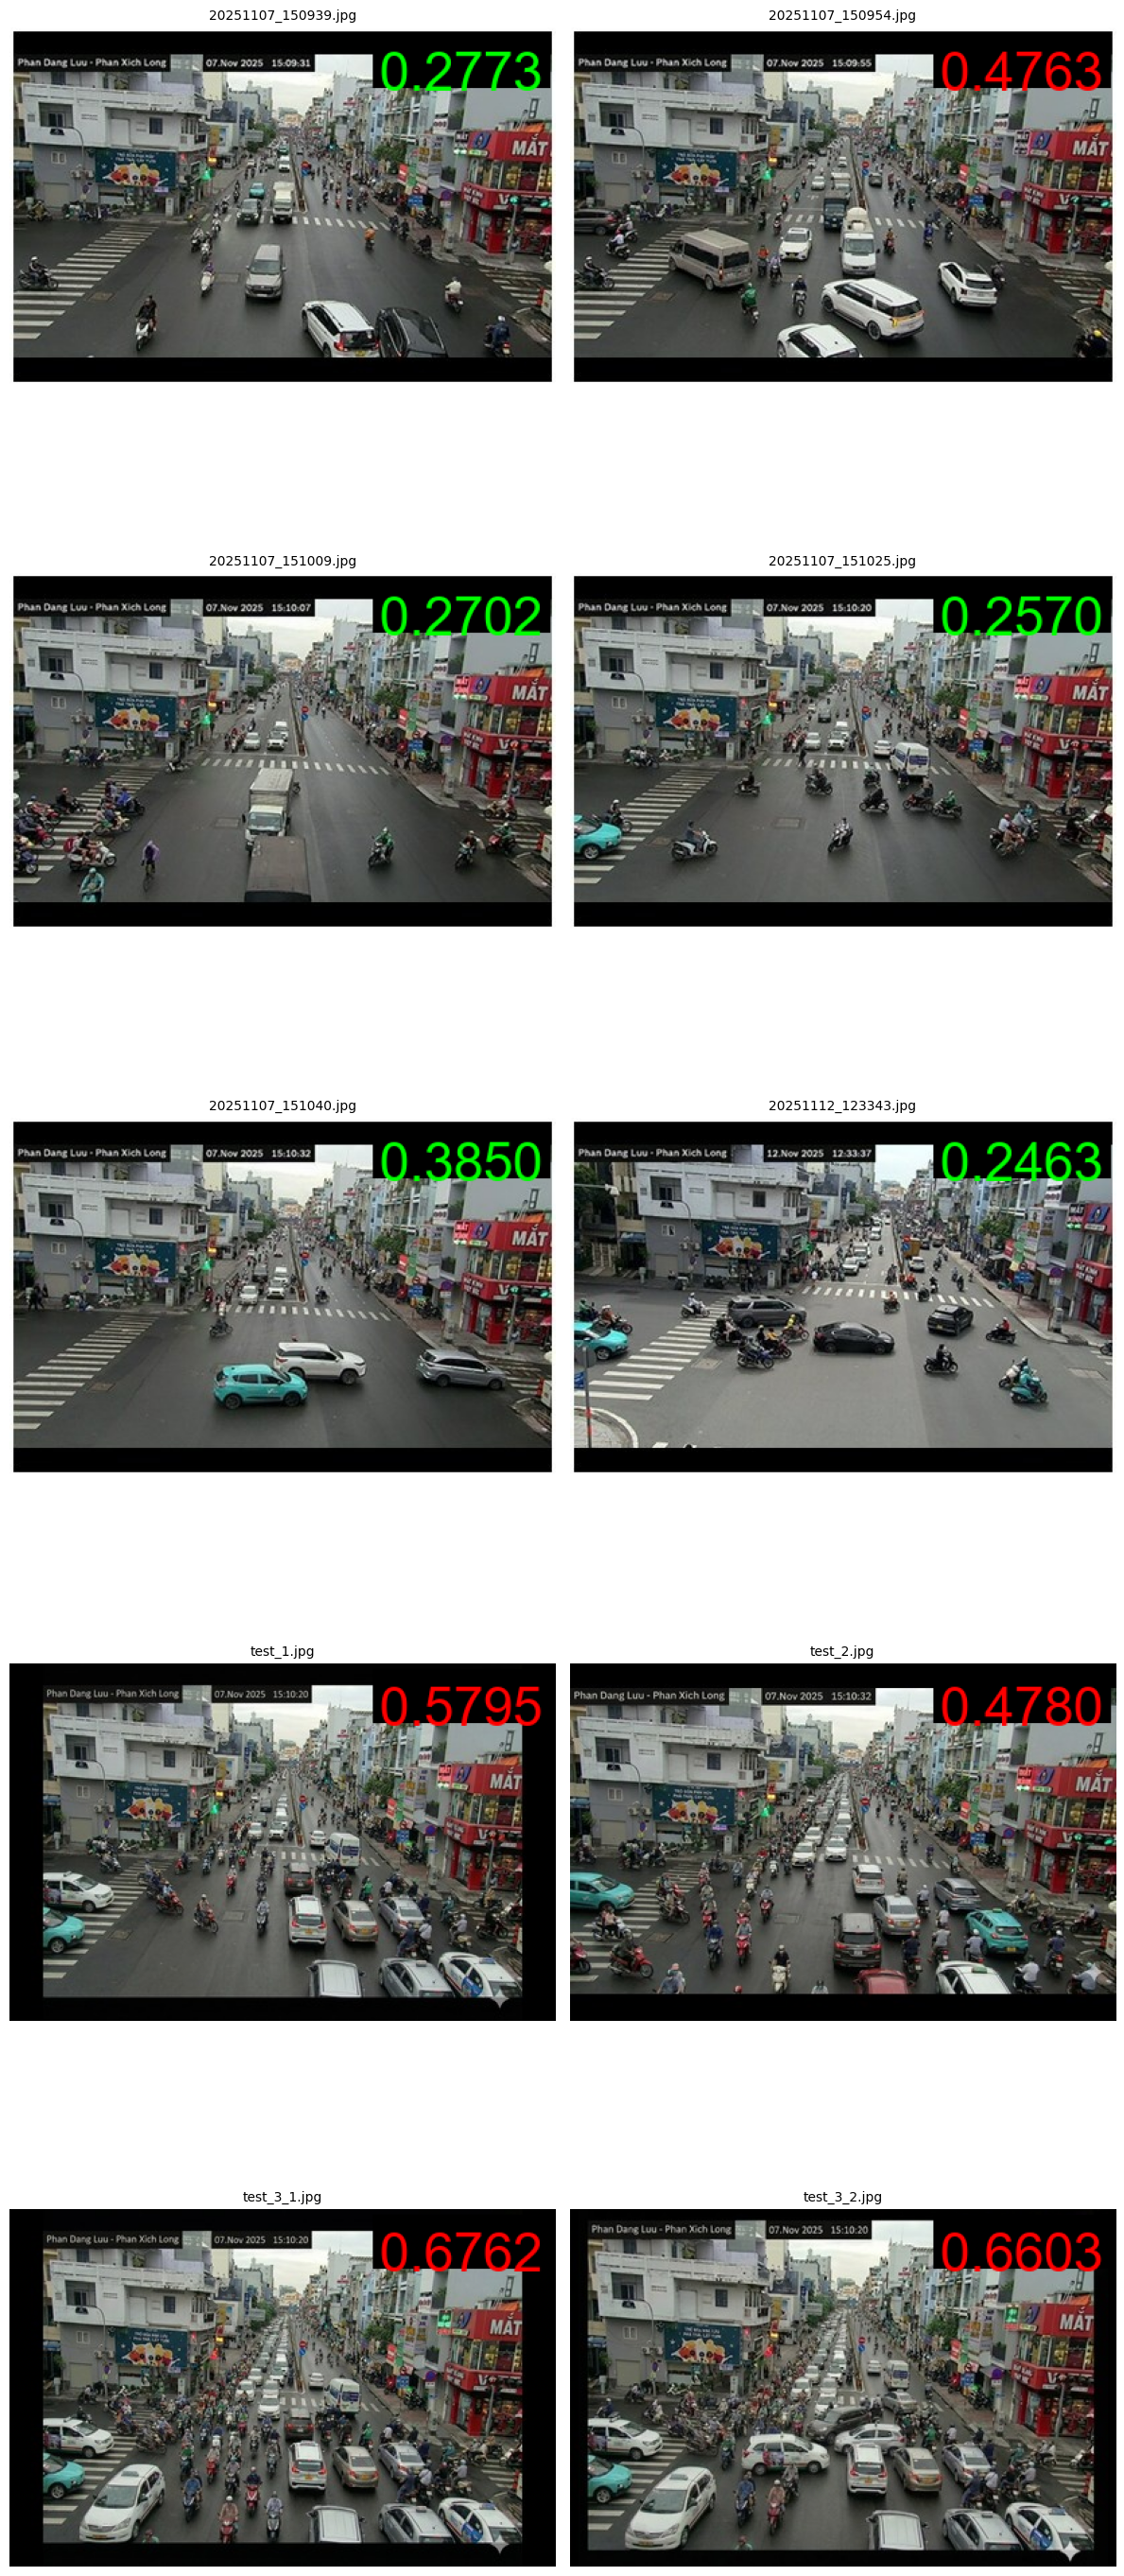

In [23]:
# display results in 2 columns
num_images = len(results)
num_cols = 2
num_rows = (num_images + num_cols - 1) // num_cols

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 6 * num_rows))
if num_rows == 1:
    axes = axes.reshape(1, -1)

for idx, (filename, score, img) in enumerate(results):
    row = idx // num_cols
    col = idx % num_cols
    
    # convert PIL to numpy for display
    img_array = np.array(img)
    
    # create a copy to draw on
    img_draw = Image.fromarray(img_array)
    draw = ImageDraw.Draw(img_draw)
    
    # add score text at top right
    text = f"{score:.4f}"
    
    # try to use a larger font, fallback to default if not available
    try:
        font = ImageFont.truetype("arial.ttf", 40)
    except:
        font = ImageFont.load_default()
    
    # get text bounding box
    bbox = draw.textbbox((0, 0), text, font=font)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    
    # position at top right with padding
    padding = 10
    x = img.width - text_width - padding
    y = padding
    
    # draw background rectangle
    draw.rectangle(
        [x - 5, y - 5, x + text_width + 5, y + text_height + 5],
        fill=(0, 0, 0, 180)
    )
    
    # draw text
    color = (0, 255, 0) if score < 0.45 else (255, 0, 0)
    draw.text((x, y), text, fill=color, font=font)
    
    # display
    axes[row, col].imshow(img_draw)
    axes[row, col].set_title(filename, fontsize=10)
    axes[row, col].axis('off')

# hide empty subplots
for idx in range(num_images, num_rows * num_cols):
    row = idx // num_cols
    col = idx % num_cols
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()